# NYC LL97 Audit Prioritization Model
**Goal:** Build a machine learning model to help the NYC Department of Buildings prioritize 
which multifamily residential buildings to audit for potential LL84 emissions misreporting.

---

In [133]:
REPORT_YEAR = '2024'

In [1]:
import requests
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

---
## 1. Data Acquisition

### 1.1 LL84 Energy and Water Disclosure Data
The LL84 dataset is sourced from NYC Open Data (resource ID: `5zyy-y8am`). It contains 
self-reported annual energy and water consumption for all NYC buildings over 25,000 sq ft.

We filter to `primary_property_type = 'Multifamily Housing'` at query time to scope the 
project to the MVP building type. The dataset contains 68,575 multifamily rows, which 
exceeds Socrata's 50,000 row per request limit — so we paginate using `$limit` and 
`$offset` parameters.

In [2]:
# load data
dfs = []
offset = 0
limit = 50000

base_url = "https://data.cityofnewyork.us/resource/5zyy-y8am.json"

while True:
    params = {
        "$where": "primary_property_type='Multifamily Housing'",
        "$limit": limit,
        "$offset": offset
    }
    batch = requests.get(base_url, params=params).json()
    if not batch:
        break
    dfs.append(pd.DataFrame(batch))
    offset += limit
    
# combine dfs
ll84_df = pd.concat(dfs, ignore_index=True)
print('LL84 df shape:')
print(ll84_df.shape)

LL84 df shape:
(68575, 265)


---
### 1.2 PLUTO DATA
PLUTO (Primary Land Use Tax Lot Output) is published by the NYC Department of City Planning 
and downloaded as a CSV. It provides physical and ownership characteristics for every tax 
lot in the five boroughs, including building age, square footage, unit count, zoning, and 
assessed value. We use it to enrich the LL84 data with building-level context for peer 
group construction and anomaly detection.

`low_memory=False` is set on import to suppress mixed-type warnings caused by pandas 
inferring dtypes chunk-by-chunk on a wide dataset.

In [3]:
pluto_df = pd.read_csv('Primary_Land_Use_Tax_Lot_Output_(PLUTO)_20260425.csv', low_memory=False)
print('PLUTO df shape:')
print(pluto_df.shape)

PLUTO df shape:
(858644, 101)


---
## 2. Data Merging

We should be able to merge `ll84_df` and `pluto_df` on BBL (Borough-Block-Lot) as it is the standard NYC property identifier. Specifically, the LL84 BBL field is `nyc_borough_block_and_lot` and the PLUTO field is `BBL`. Both are standardized to `bbl_clean` prior to joining.

**Merge results:**
- Merged rows: 68,575 (including unmatched)
- Unmerged LL84 rows: 902 (~1.3%)
- Merged dataframe shape: (68575, 367)

The 902 unmerged rows were checked for borough concentration to rule out systematic 
formatting issue. Finding no pattern, they are dropped as a negligible share of the dataset.

Duplicate columns from the merge (`latitude`, `longitude`, `borough`, `bbl_clean`) are 
resolved by keeping the PLUTO versions (ones with '_y') and dropping the LL84 duplicates (ones with '_x').

In [4]:
# Does 'bbl' in various forms exist in the dfs?

print('LL84 BBL cols:',ll84_df.columns[ll84_df.columns.str.contains('bbl', case=False)].tolist())
print('PLUTO BLL cols: ',pluto_df.columns[pluto_df.columns.str.contains('bbl', case=False)].tolist())

LL84 BBL cols: []
PLUTO BLL cols:  ['BBL', 'appbbl']


In [5]:
# closer inspection on col names
print('-'*50)
print('LL84 COLUMN NAMES')
print('-'*50)
for col in ll84_df.columns.str.lower().sort_values():
    print(col)
print('-'*50)
print('PLUTO COLUMN NAMES')
print('-'*50)
for col in pluto_df.columns.str.lower().sort_values():
    print(col)

--------------------------------------------------
LL84 COLUMN NAMES
--------------------------------------------------
_2nd_largest_property_use
_2nd_largest_property_use_1
_3rd_largest_property_use
_3rd_largest_property_use_1
address_1
adult_education_gross_floor
aggregate_meter_s_district_steam_number_of_individual_meters_included
aggregate_meter_s_electric_number_of_individual_meters_included
aggregate_meter_s_natural_gas_number_of_individual_meters_included
alert_data_center_issue_with
alert_energy_meter_has
alert_energy_meter_has_gaps
alert_energy_meter_has_less
alert_energy_meter_has_single
alert_energy_no_meters
alert_gross_floor_area_is
alert_property_has_no_uses
alert_water_meter_has_less
ambulatory_surgical_center
annual_maximum_demand_kw
annual_maximum_demand_meter
annual_maximum_demand_mm
automobile_dealership_gross
avoided_emissions_offsite
avoided_emissions_onsite
avoided_emissions_onsite_1
bank_branch_gross_floor_area
barracks_gross_floor_area
borough
city
college_unive

In [29]:
# 'nyc_borough_block_and_lot' and 'BBL' found as merge key
# function to clean keys before merging
def clean_bbl(val):
    if pd.isna(val):
        return None
    # Remove dashes, semicolons, and spaces, back and forward slashes
    clean_val = re.sub(r'[-;,\s\\/]+', '', str(val))
    # Take the first 10 digits (in case of multiple BBLs listed)
    clean_val = clean_val[:10]
    # Ensure it is 10 digits with leading zeros
    # BBL is  three components concatenated:
    # 1 digit for borough + 5 digits for block + 4 digits for lot
    # zfill (zero-padding) ensures those boundaries are consistent across both datasets so the join works correctly.
    return clean_val.zfill(10) if clean_val.isdigit() else None

# Apply cleaning to dfs
# assign returns a new unfragmented df instead of inserting cols directly
ll84_df = ll84_df.assign(
    bbl_clean=ll84_df['nyc_borough_block_and_lot'].apply(clean_bbl)
)
pluto_df = pluto_df.assign(
    bbl_clean=pluto_df['BBL'].apply(clean_bbl)
)

# Perform left join - match pluto with ll84
merged_df = pd.merge(ll84_df, pluto_df, on='bbl_clean', how='left')

print(merged_df.shape)

(68575, 367)


In [30]:
# how many rows unmerged?
unmatched_bbl = merged_df['bbl_clean'].isna().sum()
print('Percent unmerged', unmatched_bbl / merged_df.shape[0]*100)
merged_df[merged_df['bbl_clean'].isna()]['nyc_borough_block_and_lot'].value_counts()

Percent unmerged 0.6503827925628873


nyc_borough_block_and_lot
Not Available    444
q-00872/0036       1
X-XXXXX-XXXX       1
Name: count, dtype: int64

In [31]:
# how many of the rows in ll84 were left out of the merge?
unmerged = ll84_df[~ll84_df['nyc_borough_block_and_lot'].isin(merged_df['nyc_borough_block_and_lot'])]
print(unmerged['borough'].head())

Series([], Name: borough, dtype: object)


In [32]:
# clean up the merge cols
# which cols are in both dfs?
ll84_cols = set(ll84_df.columns)
pluto_cols = set(pluto_df.columns)
overlap = ll84_cols.intersection(pluto_cols)
print(overlap)

{'bbl_clean', 'borough', 'longitude', 'latitude'}


In [33]:
# 'bbl_clean', 'latitude', 'longitude', 'borough' are common between dfs
# we merged on 'bbl_clean' so resolve the others
# pandas adds _x (left df -ll84) and _y (right df -pluto) is added to the cols
#  we keep use _y since pluto is the definitive geocoded location
cols_to_drop = ['latitude_x', 'longitude_x', 'borough_x']
merged_df = merged_df.drop(columns=cols_to_drop)

# clean/rename up the _y suffixes on the ones we're keeping
merged_df = merged_df.rename(columns={
    'latitude_y': 'latitude',
    'longitude_y': 'longitude',
    'borough_y': 'borough',
    'bbl_clean_y': 'bbl_clean'
})

---
## 3. Exploratory Data Analysis

### 3.1 Data Quality Assessment

#### Replacing "Not Available" Strings
LL84 uses "Not Available" as a string placeholder throughout rather than true nulls. We
replace these with NaN before any null analysis to get accurate missingness rates.

#### Null Rate Analysis
We drop any column where more than 80% of values are null. This threshold captures five
categories of uninformative columns:

- **Other property type columns** — fields like `convention_center_gross_floor` and
`hospital_general_medical` are 100% null because we filtered to multifamily only
- **Data center columns** — same reason
- **Unused fuel types** — `kerosene_use_kbtu`, `propane_use_kbtu`, and district
steam/hot water/chilled water are largely absent for multifamily buildings
- **PLUTO administrative date columns** — internal DCP timestamps (`zoningdate`,
`masdate`, `landmkdate` etc.) only populated when specific regulatory actions occur
- **PLUTO secondary zoning columns** — `zonedist2/3/4`, `overlay1/2` rarely populated

One candidate — `district_steam_use_kbtu` — was checked manually before dropping.
Despite pre-war Manhattan buildings commonly using Con Edison steam, only 1,570 buildings
(2.3%) had values. Excluded from the feature set due to sparsity and potential geographic
bias toward Manhattan.

**Result:** Dropped 169 columns, reducing from 367 to 198.

### 3.2 Data Quality Flag Analysis
EPA's Portfolio Manager includes alert flags and estimation indicators for each submission.
We examine these for variation before deciding whether to include them as model features.

Alert columns with meaningful "Possible Issue" counts are retained. Three columns with
zero variation (all "Ok") are dropped: `alert_property_has_no_uses`,
`alert_data_center_issue_with`, and `alert_gross_floor_area_is`.

`estimated_values_energy` (38% "Yes") and `estimated_data_flag` (21% "Yes") both show
meaningful variation and are retained as weak anomaly signals — buildings with estimated
rather than metered data are more likely to diverge from actual consumption.

### 3.3 Feature Selection
We narrow the dataset to 33 features grouped into five categories plus 7 identifier
columns, producing `model_df` at (68,575, 40).


### 3.4 Target Variable Distribution

`total_location_based_ghg` measures total greenhouse gas emissions in metric tons CO2e
per year and is the anchor variable for anomaly detection.

The raw distribution is heavily right-skewed — median emissions are 294 metric tons but
the mean is 638, pulled upward by large outliers reaching 2,206,863 metric tons. This
reflects the mix of small walk-up buildings and large residential complexes in the dataset.

839 buildings (1.4%) report zero emissions, which is implausible for an occupied
multifamily building and may itself indicate misreporting. These are retained in the
dataset as potential anomaly candidates.

Log1p transformation produces an approximately normal distribution, suggesting
log-transforming emission features before modeling is appropriate.

In [34]:
# replace 'Not Available' with nan
pattern = r'(?i)^\s*not available\s*$'
# .mask() - keep the data as is, unless it matches the condition
merged_df = merged_df.mask(merged_df.apply(lambda x: x.astype(str).str.match(pattern)), np.nan)

In [35]:
# what is the percent of null values in each col? 
# isnull() - T/F where 1/0 so mean() gets the percentage
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
null_rates = merged_df.isnull().mean().sort_values(ascending=False)

<Axes: >

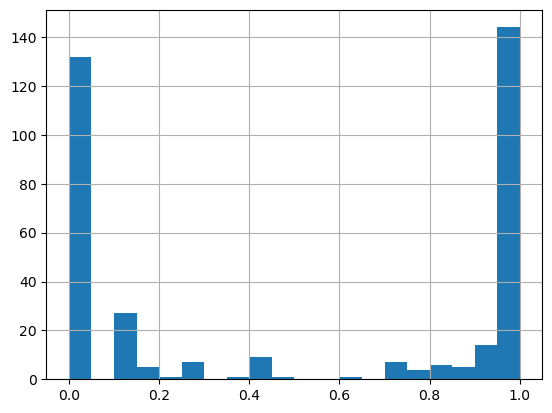

In [36]:
null_rates.hist(bins=20)

In [37]:
# quite a lot of cols with high null rates. which cols have 0.8 or more nulls
null_rates = merged_df.isnull().mean().sort_values(ascending=False)
cols_to_drop = null_rates[null_rates >= 0.80]
print(f"{len(cols_to_drop)} columns to drop:\n")
print(cols_to_drop)

169 columns to drop:

zoningdate                                      1.000000
notes                                           1.000000
data_center_national_median                     1.000000
data_center_pue                                 1.000000
convention_center_gross_floor                   1.000000
district_hot_water_use_kbtu                     1.000000
kerosene_use_kbtu                               1.000000
propane_use_kbtu                                1.000000
refrigerated_warehouse_gross                    1.000000
wastewater_treatment_plant                      1.000000
municipally_supplied_potable_3                  1.000000
energy_star_certification_application_status    1.000000
barracks_gross_floor_area                       1.000000
dcasdate                                        1.000000
spdist3                                         1.000000
geom                                            1.000000
polidate                                        1.000000
landmkdat

In [38]:
# 'district_steam_use_kbtu' having 0.8 null could be real
# since older pre-war buildings use steam
# check for number of rows not null
print(merged_df['district_steam_use_kbtu'].notna().sum())

1570


In [39]:
# drop cols with more than 0.8
null_rates = merged_df.isnull().mean()
merged_df = merged_df[null_rates[null_rates < 0.80].index]
print(merged_df.shape)

(68575, 195)


In [40]:
# what are the counts for estimated_values_energy and estimated_data_flag
# rows where EPA estimated the data rather than using actual meter readings
# Potentially very useful as a weak label for suspicious reporting
print(merged_df['estimated_values_energy'].value_counts())
print(merged_df['estimated_data_flag'].value_counts())

estimated_values_energy
No                                   35899
Yes                                  26322
Unable to Check (not enough data)     6354
Name: count, dtype: int64
estimated_data_flag
No     46409
Yes    14408
Name: count, dtype: int64


In [19]:
# both estimated_values_energy and estimated_data_flag worth keeping
# 38% means a significant share of buildings had their energy data
# estimated by EPA's Portfolio Manager rather than pulled from actual
# meter readings. 
# estimated data is more likely to diverge from reality and is a legitimate anomaly signal

In [265]:
# define features and build model_df
feature_cols = [
    # Emissions and energy — core anomaly signals
    'total_location_based_ghg',
    'direct_ghg_emissions_metric',
    'site_eui_kbtu_ft',
    'source_eui_kbtu_ft',
    'site_energy_use_kbtu',
    'weather_normalized_site_eui',
    'electricity_use_grid_purchase',
    'natural_gas_use_kbtu',
    'energy_star_score',
    
    'ghg_per_sqft',
    'ghg_per_unit', 
    'site_eui_per_unit',

    # Building physical characteristics — peer grouping
    'multifamily_housing_gross',
    'yearbuilt',
    'numbldgs',
    'numfloors',
    'unitsres',
    'bldgarea',
    'lotarea',

    # Ownership and assessment — risk signals
    'assesstot',
    'ownername',

    # Geographic — peer grouping
    'borough',
    'zonedist1',
    'postcode',

    # Reporting metadata — anomaly signals
    'occupancy',
    'number_of_buildings',
    'property_gfa_self_reported',
    'property_gfa_calculated',

    # Data quality flags — weak labels
    'estimated_values_energy',
    'estimated_data_flag',
    'alert_energy_meter_has_less',
    'alert_energy_meter_has_gaps',
    'alert_energy_meter_has',
    'alert_energy_no_meters',
    'alert_energy_meter_has_single',
    'alert_water_meter_has_less',
]

id_cols = [
    'property_id',
    'bbl_clean',
    'address_1',
    'property_name',
    'nyc_borough_block_and_lot',
    'latitude',
    'longitude',
    'report_year'
]


In [267]:
# BUILD MODEL DF
model_df = merged_df[id_cols + feature_cols].copy()
print(model_df.shape)

(68575, 41)


In [268]:
# FILTER BASED ON YEAR
model_df = model_df[model_df['report_year'] == REPORT_YEAR]
print(model_df.shape)

(26613, 41)


In [269]:
# Split into private and NYCHA populations
# NYCHA flagged at 40% vs 4% for private buildings — structural differences
# in campus-style reporting warrant separate treatment
nycha_mask = model_df['ownername'] == 'NYC HOUSING AUTHORITY'
model_df_nycha = model_df[nycha_mask].copy()
model_df = model_df[~nycha_mask].copy()

print(f"Private buildings: {model_df.shape[0]}")
print(f"NYCHA buildings: {model_df_nycha.shape[0]}")

Private buildings: 26010
NYCHA buildings: 603


In [209]:
# Check null rates in model_df
print(model_df.isnull().mean().sort_values(ascending=False).head(15))

energy_star_score                0.309689
weather_normalized_site_eui      0.262361
direct_ghg_emissions_metric      0.250019
natural_gas_use_kbtu             0.248558
electricity_use_grid_purchase    0.242561
total_location_based_ghg         0.233372
site_eui_kbtu_ft                 0.233295
site_energy_use_kbtu             0.233295
source_eui_kbtu_ft               0.233295
estimated_data_flag              0.231180
numfloors                        0.015609
zonedist1                        0.010688
latitude                         0.009765
postcode                         0.009765
longitude                        0.009765
dtype: float64


In [210]:
# Check dtypes — how many columns still need type conversion
print(model_df.dtypes.value_counts())

object     35
float64     6
Name: count, dtype: int64


In [211]:
# of the buildings missing ghg, are the same buildings also missing everything else?"
energy_nulls = model_df['total_location_based_ghg'].isna()
print(model_df[energy_nulls][['site_eui_kbtu_ft', 'energy_star_score', 'natural_gas_use_kbtu']].isna().mean())

site_eui_kbtu_ft        0.999671
energy_star_score       0.999835
natural_gas_use_kbtu    0.963756
dtype: float64


In [212]:
# 0.93+ missing buildings with no useable energy data
# how many of them
print(model_df['total_location_based_ghg'].isna().sum())

6070


In [213]:
# about 7200 of 68000 with no energy data. 61k is reasonable number of rows to train
# drop null emissions rows
model_df = model_df.dropna(subset=['total_location_based_ghg'])
print(model_df.shape)

(19940, 41)


---
## 4. Feature Engineering

### 4.1 Type Conversion and Data Preparation

#### Drop Null Emissions Rows
Rows where `total_location_based_ghg` is null are dropped prior to type conversion.
Cross-checking revealed that 99% of these rows were also null across all other core
energy features (`site_eui_kbtu_ft`, `energy_star_score`, `natural_gas_use_kbtu`),
making imputation inappropriate. This removes 7,254 buildings (10.6%), leaving 61,321
for modeling.

#### Numeric Type Conversion
19 columns arrived as strings from the Socrata API despite containing numeric values.
These are converted to float64/int64 using `pd.to_numeric(errors='coerce')`, which
converts unparseable values to NaN rather than raising errors.

#### Flag Encoding
Alert columns are encoded as ordinal integers:
- `Ok` → 0
- `Possible Issue` → 1  
- `Unable to Check (not enough data)` → 2

#### Estimated Data Flags Dropped
After dropping null emissions rows, `estimated_values_energy` and `estimated_data_flag`
contained only NaN and "Unable to Check" values — all "Yes"/"No" signal was lost. This
reveals that the buildings flagged as having estimated data were the same buildings
missing emissions data entirely. Both columns are dropped as they carry no remaining
signal in the modeling dataset.

### Categorical Encoding

#### Borough
Borough has 5 unique values (MN, BK, BX, QN, SI) and is one-hot encoded using
`pd.get_dummies`. Manhattan and Brooklyn together account for nearly 60% of the dataset.

#### Zoning District
The raw `zonedist1` column contains 166 unique zoning designations — too high cardinality
for direct encoding. We simplify by extracting the zoning prefix (e.g. `R7-1` → `R7`,
`C6B` → `C6`), which collapses 166 categories to 19 meaningful zoning classes.

The dataset is predominantly R zones (residential) as expected for multifamily buildings.
C zones (commercial/mixed-use) account for ~7,000 buildings and M zones (manufacturing)
account for ~2,250 — the latter is unusual for residential use and may itself be a weak
anomaly signal.

Both `borough` and `zoning_prefix` are one-hot encoded with `drop_first=False` to retain
full category representation, appropriate for unsupervised anomaly detection where no
reference category is needed.

**Result:** `model_df` expands from 40 to 61 columns after encoding.

In [214]:
# check which cols should be numeric
# print(model_df.select_dtypes(include='object').columns.tolist())
cols_df = pd.DataFrame(model_df.select_dtypes(include='object').columns.tolist())
cols_df

,0
0,property_id
1,bbl_clean
2,address_1
3,property_name
4,nyc_borough_block_and_lot
5,report_year
6,total_location_based_ghg
7,direct_ghg_emissions_metric
8,site_eui_kbtu_ft
9,source_eui_kbtu_ft


In [215]:
# convert to float
numeric_cols = [
    'total_location_based_ghg', 'direct_ghg_emissions_metric',
    'site_eui_kbtu_ft', 'source_eui_kbtu_ft', 'site_energy_use_kbtu',
    'weather_normalized_site_eui', 'electricity_use_grid_purchase',
    'natural_gas_use_kbtu', 'energy_star_score', 'multifamily_housing_gross',
    'numbldgs', 'unitsres', 'assesstot',
    'occupancy', 'number_of_buildings', 'property_gfa_self_reported',
    'property_gfa_calculated'
]

# encode as binary
flag_cols = [
    'estimated_values_energy', 'estimated_data_flag',
    'alert_energy_meter_has_less', 'alert_energy_meter_has_gaps',
    'alert_energy_meter_has', 'alert_energy_no_meters',
    'alert_energy_meter_has_single', 'alert_water_meter_has_less',
]

# identifiers: property_id, bbl_clean, address_1, property_name, nyc_borough_block_and_lot, ownername
# categoricals for peer grouping: borough, zonedist1

In [271]:
# change numeric cols
for col in numeric_cols:
    model_df[col] = pd.to_numeric(model_df[col], errors='coerce')

print(model_df[numeric_cols].dtypes.value_counts())

float64    15
int64       2
Name: count, dtype: int64


In [273]:
# Size-normalized emissions features
# These ask whether emissions are anomalous relative to building size
# rather than flagging large buildings purely because of scale
model_df['ghg_per_sqft'] = model_df['total_location_based_ghg'] / model_df['multifamily_housing_gross']
model_df['ghg_per_unit'] = model_df['ghg_per_unit'].replace([np.inf, -np.inf], np.nan)
model_df['site_eui_per_unit'] = model_df['site_eui_per_unit'].replace([np.inf, -np.inf], np.nan)

print(model_df[['ghg_per_sqft', 'ghg_per_unit', 'site_eui_per_unit']].describe())

       ghg_per_sqft  ghg_per_unit  site_eui_per_unit
count  19940.000000  19532.000000       19533.000000
mean       0.409294      7.353045          42.447717
std        9.654952     28.304724        1468.988481
min        0.000000      0.000000           0.000000
25%        0.004045      4.140649           0.622449
50%        0.005023      5.285663           1.200000
75%        0.006279      7.033771           2.035714
max      599.420000   1947.615000      170990.606061


In [274]:
print(model_df[model_df['ghg_per_sqft'] > 10][['address_1', 'property_name', 
                                                 'ghg_per_sqft', 'total_location_based_ghg',
                                                 'multifamily_housing_gross']].head(10))

                   address_1  \
51838         691 Ocean Pkwy   
51844         260 Myrtle Ave   
51845         115 Ashland Pl   
51846         125 Ashland PL   
51847         135 Ashland PL   
51848   130 Saint Edwards St   
51851           383 Bay 8 st   
51856  1453 Independence Ave   
51858        1051 Shore Pkwy   
51860        1083 Shore Pkwy   

                                           property_name  ghg_per_sqft  \
51838                                   (691 Ocean Pkwy)         14.52   
51844                   Kingsview Homes (260 Myrtle Ave)        111.91   
51845                   Kingsview Homes (115 Ashland Pl)         48.02   
51846                   Kingsview Homes (125 Ashland Pl)         56.18   
51847                   Kingsview Homes (135 Ashland Pl)         60.75   
51848             Kingsview Homes (130 Saint Edwards St)         56.35   
51851       Independence Gardens Owners 2 (383 Bay 8 st)         98.21   
51856  Independence Gardens Owners 2 (1453 Independen..

In [275]:
# Flag implausible square footage — buildings under 1000 sqft are almost certainly errors
model_df.loc[model_df['multifamily_housing_gross'] < 1000, 'ghg_per_sqft'] = np.nan
print(f"Buildings with multifamily_housing_gross < 1000: {(model_df['multifamily_housing_gross'] < 1000).sum()}")

Buildings with multifamily_housing_gross < 1000: 220


In [276]:
model_df['ghg_per_unit'] = model_df['ghg_per_unit'].replace([np.inf, -np.inf], np.nan)
model_df['site_eui_per_unit'] = model_df['site_eui_per_unit'].replace([np.inf, -np.inf], np.nan)

# Verify no more infs
print(model_df[['ghg_per_sqft', 'ghg_per_unit', 'site_eui_per_unit']].describe())

       ghg_per_sqft  ghg_per_unit  site_eui_per_unit
count  19884.000000  19532.000000       19533.000000
mean       0.005569      7.353045          42.447717
std        0.006406     28.304724        1468.988481
min        0.000000      0.000000           0.000000
25%        0.004042      4.140649           0.622449
50%        0.005018      5.285663           1.200000
75%        0.006268      7.033771           2.035714
max        0.489835   1947.615000      170990.606061


In [277]:
print(model_df[model_df['unitsres'] < 5][['address_1', 'unitsres', 
                                           'ghg_per_unit', 
                                           'multifamily_housing_gross']].head(10))
print(f"\nBuildings with unitsres < 5: {(model_df['unitsres'] < 5).sum()}")


                     address_1  unitsres  ghg_per_unit  \
42504    216 West 100th Street       0.0           NaN   
42845         420 East 70th St       0.0           NaN   
42886      660 West End Avenue       0.0           NaN   
42923  2475 Southern Boulevard       0.0           NaN   
42924  2375 Southern Boulevard       0.0           NaN   
43186     341 West 38th Street       0.0           NaN   
43372    1116 Amsterdam Avenue       0.0           NaN   
43449       600 West 42 Street       3.0       1220.77   
43581        42 EAST 98 STREET       0.0           NaN   
43582         1247 PARK AVENUE       0.0           NaN   

       multifamily_housing_gross  
42504                    87305.0  
42845                   170410.0  
42886                   236860.0  
42923                   319535.0  
42924                   160250.0  
43186                   100522.0  
43372                    87522.0  
43449                  1045712.0  
43581                   244000.0  
43582      

In [278]:
# Buildings with fewer than 5 units are almost certainly data entry errors
# LL97 covered buildings over 25,000 sqft cannot legitimately have 0-3 units
model_df.loc[model_df['unitsres'] < 5, 'ghg_per_unit'] = np.nan
model_df.loc[model_df['unitsres'] < 5, 'site_eui_per_unit'] = np.nan

print(model_df[['ghg_per_sqft', 'ghg_per_unit', 'site_eui_per_unit']].describe())

       ghg_per_sqft  ghg_per_unit  site_eui_per_unit
count  19884.000000  19483.000000       19484.000000
mean       0.005569      6.530355          42.445445
std        0.006406      7.363995        1470.832181
min        0.000000      0.000000           0.000000
25%        0.004042      4.135938           0.621031
50%        0.005018      5.280714           1.197425
75%        0.006268      7.012361           2.023634
max        0.489835    563.108047      170990.606061


In [279]:

print(model_df['estimated_values_energy'].value_counts(dropna=False))
print(model_df['estimated_data_flag'].value_counts(dropna=False))

estimated_values_energy
Yes                                  11396
No                                    9137
Unable to Check (not enough data)     5477
Name: count, dtype: int64
estimated_data_flag
No     14420
NaN     6013
Yes     5577
Name: count, dtype: int64


In [280]:
# Encode flag_cols
alert_cols = [
    'alert_energy_meter_has_less',
    'alert_energy_meter_has_gaps',
    'alert_energy_meter_has',
    'alert_energy_no_meters',
    'alert_energy_meter_has_single',
    'alert_water_meter_has_less',
]

alert_flag_map = {
    'Ok': 0,
    'Possible Issue': 1,
    'Unable to Check (not enough data)': 2
}

for col in alert_cols:
    model_df[col] = model_df[col].map(alert_flag_map)

# Yes / No / Unable to Check
estimated_energy_map = {
    'No': 0, 
    'Yes': 1, 
    'Unable to Check (not enough data)': 2
}
# Encode estimated data flags separately — different value sets
model_df['estimated_values_energy'] = model_df['estimated_values_energy'].map(estimated_energy_map)

# Yes / No only
estimated_flag_map = {
    'No': 0, 
    'Yes': 1
}
model_df['estimated_data_flag'] = model_df['estimated_data_flag'].map(estimated_flag_map)

print(model_df[alert_cols + ['estimated_values_energy', 'estimated_data_flag']].dtypes.value_counts())
print(model_df[['estimated_values_energy', 'estimated_data_flag']].value_counts(dropna=False))

int64      7
float64    1
Name: count, dtype: int64
estimated_values_energy  estimated_data_flag
0                        0.0                    8611
1                        0.0                    5809
                         1.0                    5577
2                        NaN                    5477
0                        NaN                     526
1                        NaN                      10
Name: count, dtype: int64


In [281]:
# check distribution by borough
print(model_df['borough'].value_counts())
# print(model_df['zonedist1'].value_counts())

borough
MN    7821
QN    6780
BK    6160
BX    4661
SI     358
Name: count, dtype: int64


In [282]:
# zonedist1 means primary zoning district from PLUTO
# 166 too many unique values so get zoning prefix
# C - Commercial (resident above commericial/mixed use)
# R - Residential (higher numbers mean more density)
# M - Manufacturing (residential grandfathered pre-zoning or misclassified)
# https://www.nyc.gov/content/planning/pages/zoning/zoning-nyc
# https://zr.planning.nyc.gov (zoning resolution)

print(f"Unique zoning districts: {model_df['zonedist1'].nunique()}")
model_df['zoning_prefix'] = model_df['zonedist1'].str.extract(r'^([A-Z]+\d)')
print(f"Unique zoning prefixes: {model_df['zoning_prefix'].nunique()}")
print(model_df['zoning_prefix'].value_counts())

Unique zoning districts: 163
Unique zoning prefixes: 19
zoning_prefix
R7    6655
R6    4933
R8    3098
R4    2117
R5    2050
R3    2011
C6    1132
R1     948
M1     854
C4     600
C1     539
C5     365
C2     175
R9     136
R2      31
C8      26
M3      13
M2      10
C3       6
Name: count, dtype: int64


In [283]:
# encode borough and zoning_prefix
model_df = pd.get_dummies(model_df, columns=['borough', 'zoning_prefix'], drop_first=False)
print(model_df.shape)

(26010, 67)


### 4.2 Peer Group Construction

We construct a peer group variable by combining building age and size buckets, enabling
the anomaly detection model to compare each building against structurally similar peers
rather than the full population.

#### Age Buckets
`yearbuilt` is binned into five categories:
- `pre_war` — built before 1940 (33,556 buildings, 55% of dataset)
- `post_war` — 1940–1970 (12,736)
- `late_20c` — 1970–1990 (3,333)
- `modern` — 1990–2010 (5,653)
- `recent` — 2010–2030 (5,293)

#### Size Buckets
`multifamily_housing_gross` is binned into four categories:
- `small` — under 50,000 sq ft (24,734)
- `medium` — 50,000–100,000 sq ft (20,164)
- `large` — 100,000–250,000 sq ft (11,579)
- `xl` — over 250,000 sq ft (4,844)

#### Peer Group Variable
Age and size buckets are concatenated into a single `peer_group` label (e.g.
`pre_war_small`, `post_war_medium`), producing 20 unique peer groups across 60,531
buildings. 

750 buildings with null square footage in both `multifamily_housing_gross` and `bldgarea` could not be assigned a size bucket and are dropped.

`lotarea` and `bldgarea` are dropped after peer group construction as both
are 99.9% null and superseded by `multifamily_housing_gross`.

**Result:** `model_df` at (60571, 64)

In [284]:
# Age buckets
model_df['age_bucket'] = pd.cut(
    model_df['yearbuilt'],
    bins=[0, 1940, 1970, 1990, 2010, 2030],
    labels=['pre_war', 'post_war', 'late_20c', 'modern', 'recent']
)
print(model_df['age_bucket'].value_counts())

age_bucket
pre_war     12039
post_war     8009
recent       2202
modern       2108
late_20c     1351
Name: count, dtype: int64


In [285]:
# Size buckets based on gross floor area
model_df['size_bucket'] = pd.cut(
    model_df['multifamily_housing_gross'],
    bins=[0, 50000, 100000, 250000, float('inf')],
    labels=['small', 'medium', 'large', 'xl']
)
print(model_df['size_bucket'].value_counts())

size_bucket
small     13014
medium     7336
large      4198
xl         1462
Name: count, dtype: int64


In [286]:
model_df['peer_group'] = model_df['age_bucket'].astype(str) + '_' + model_df['size_bucket'].astype(str)
print(f"Unique peer groups: {model_df['peer_group'].nunique()}")
print(model_df['peer_group'].value_counts())

Unique peer groups: 24
peer_group
pre_war_small      6429
post_war_small     4227
pre_war_medium     4132
post_war_medium    1642
post_war_large     1579
pre_war_large      1311
modern_small        978
recent_small        880
modern_medium       590
recent_medium       589
post_war_xl         561
recent_large        480
late_20c_large      405
late_20c_small      394
modern_large        369
late_20c_medium     297
late_20c_xl         255
recent_xl           253
modern_xl           171
pre_war_xl          167
nan_small           106
nan_medium           86
nan_xl               55
nan_large            54
Name: count, dtype: int64


In [287]:
nan_size = model_df['size_bucket'].isna()
print(model_df[nan_size][['multifamily_housing_gross', 'bldgarea']].describe())

       multifamily_housing_gross
count                        0.0
mean                         NaN
std                          NaN
min                          NaN
25%                          NaN
50%                          NaN
75%                          NaN
max                          NaN


In [288]:
model_df = model_df[model_df['size_bucket'].notna()]
print(model_df.shape)

(26010, 70)


In [289]:
print(model_df['size_bucket'].isna().sum())
print(model_df['peer_group'].str.startswith('nan').sum())

0
301


In [290]:
model_df = model_df[~model_df['peer_group'].str.startswith('nan')]
print(model_df.shape)

(25709, 70)


In [291]:
print(model_df['peer_group'].value_counts())
print(model_df.isnull().mean().sort_values(ascending=False).head(10))

peer_group
pre_war_small      6429
post_war_small     4227
pre_war_medium     4132
post_war_medium    1642
post_war_large     1579
pre_war_large      1311
modern_small        978
recent_small        880
modern_medium       590
recent_medium       589
post_war_xl         561
recent_large        480
late_20c_large      405
late_20c_small      394
modern_large        369
late_20c_medium     297
late_20c_xl         255
recent_xl           253
modern_xl           171
pre_war_xl          167
Name: count, dtype: int64
energy_star_score                0.308024
weather_normalized_site_eui      0.262126
direct_ghg_emissions_metric      0.249407
natural_gas_use_kbtu             0.247968
ghg_per_unit                     0.244584
site_eui_per_unit                0.244545
electricity_use_grid_purchase    0.239527
ghg_per_sqft                     0.235132
total_location_based_ghg         0.232953
site_energy_use_kbtu             0.232876
dtype: float64


In [292]:
# lotarea and bldgarea is 99% null, dropping
model_df = model_df.drop(columns=['lotarea', 'bldgarea'])
print(model_df.shape)

(25709, 68)


In [293]:
# Checking for zero or negative emissions values
# log transformation requires positive values (log(0) = -inf)
# zero emissions is also implausible for an occupied multifamily building
# and may itself indicate misreporting — retained as anomaly candidates
print((model_df['total_location_based_ghg'] <= 0).sum())

18


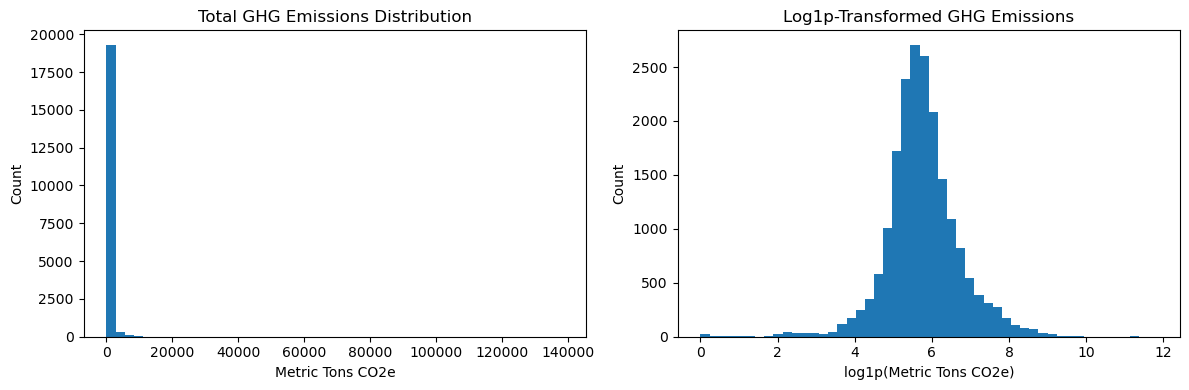

count     19720.000000
mean        546.653415
std        1714.170414
min           0.000000
25%         190.377500
50%         299.105000
75%         503.325000
max      138481.470000
Name: total_location_based_ghg, dtype: float64


In [294]:
# Plot raw and log1p-transformed distributions of total GHG emissions
# Raw distribution reveals skewness and outliers
# Log1p transformation (log(1+x)) handles zero values and normalizes the distribution
# A roughly normal log distribution confirms log-transforming emission features 
# before modeling is appropriate — Isolation Forest and LOF use distance-based 
# calculations that would be dominated by extreme outliers in raw scale

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

target = model_df['total_location_based_ghg']

axes[0].hist(target, bins=50)
axes[0].set_title('Total GHG Emissions Distribution')
axes[0].set_xlabel('Metric Tons CO2e')
axes[0].set_ylabel('Count')

axes[1].hist(np.log1p(target), bins=50)
axes[1].set_title('Log1p-Transformed GHG Emissions')
axes[1].set_xlabel('log1p(Metric Tons CO2e)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(target.describe())

The raw distribution (left panel) shows almost all 60,000+ buildings compressed into a sliver near zero, with a handful of extreme outliers stretching toward 2.2 million metric tons. This is a classic right-skewed distribution — the mean (638) is more than double the median (294) because a small number of very large buildings pull the average up dramatically.

The log1p distribution (right panel) produces a clean bell curve centered around 5-6, which corresponds to roughly 150-400 metric tons in raw scale. The small isolated spike at 0 on the left is your 839 zero-emissions buildings — visually separated from the main population, which is a good early sign that the model will naturally flag these as anomalies.

The practical implication for modeling is to log-transform the continuous emissions features before fitting Isolation Forest and LOF. Without it, the model's distance calculations would be almost entirely driven by the handful of extreme outliers rather than the meaningful variation across the bulk of the dataset.

### 4.3 Feature Matrix

The feature matrix is the structured numerical input the model trains on. Unlike `model_df`,
which still contains identifier columns, string columns, and categoricals, the feature matrix
`X` contains only columns that carry predictive signal, all converted to numeric types with
no nulls. Identifier columns are set aside and rejoined to model output after scoring so
results can be mapped back to specific buildings and addresses.

Non-numeric columns are excluded from the feature matrix:
- **Identifiers** (`property_id`, `bbl_clean`, `address_1`, `property_name`,
`nyc_borough_block_and_lot`) — carried separately for output joining
- **`ownername`** — too high cardinality (uniqueness) to encode meaningfully; retained as metadata
for post-model analysis (e.g. flagging owners with multiple anomalous buildings)
- **`zonedist1`** — superseded by `zoning_prefix` one-hot columns
- **`peer_group`** — used for grouping logic, not a direct model input

`age_bucket` and `size_bucket` (category dtype from `pd.cut`) are one-hot encoded
before fitting as sklearn cannot handle category dtype directly.

Remaining nulls are imputed using median strategy via `SimpleImputer` — appropriate
given the right-skewed distributions confirmed in section 3.2. `energy_star_score`
had the highest null count at 6,225 (10.3%).

**Result:** Feature matrix `X_imputed` at (60,531, 61) with zero nulls. Ready for modeling.

In [295]:
# what are the object cols?
print(model_df.select_dtypes(include='object').columns.tolist())

['property_id', 'bbl_clean', 'address_1', 'property_name', 'nyc_borough_block_and_lot', 'report_year', 'ownername', 'zonedist1', 'peer_group']


In [296]:
# prepare feature matrix, X
exclude_cols = [
    'property_id', 'bbl_clean', 'address_1', 'property_name',
    'nyc_borough_block_and_lot', 'ownername', 'zonedist1', 'peer_group'
]

X = model_df.drop(columns=exclude_cols)
print(X.shape)
print(X.dtypes.value_counts())

(25709, 60)
float64     24
bool        24
int64        9
object       1
category     1
category     1
Name: count, dtype: int64


In [297]:
# encode category cols
X = pd.get_dummies(X, columns=['age_bucket', 'size_bucket'], drop_first=False)
print(X.shape)
print(X.dtypes.value_counts())

(25709, 67)
bool       33
float64    24
int64       9
object      1
Name: count, dtype: int64


In [298]:
print(X.isnull().sum().sort_values(ascending=False).head(10))

energy_star_score                7919
weather_normalized_site_eui      6739
direct_ghg_emissions_metric      6412
natural_gas_use_kbtu             6375
ghg_per_unit                     6288
site_eui_per_unit                6287
electricity_use_grid_purchase    6158
ghg_per_sqft                     6045
total_location_based_ghg         5989
source_eui_kbtu_ft               5987
dtype: int64


In [299]:
null_cols = ['energy_star_score', 'weather_normalized_site_eui', 
             'natural_gas_use_kbtu', 'electricity_use_grid_purchase']

for col in null_cols:
    print(f"\n{col}")
    print(model_df[col].describe())


energy_star_score
count    17790.000000
mean        62.702979
std         29.380256
min          1.000000
25%         41.000000
50%         68.000000
75%         88.000000
max        100.000000
Name: energy_star_score, dtype: float64

weather_normalized_site_eui
count    1.897000e+04
mean     8.381243e+03
std      1.954111e+05
min      0.000000e+00
25%      5.550000e+01
50%      7.390000e+01
75%      9.220000e+01
max      1.173531e+07
Name: weather_normalized_site_eui, dtype: float64

natural_gas_use_kbtu
count    1.933400e+04
mean     5.044812e+06
std      2.584662e+07
min      0.000000e+00
25%      9.807560e+05
50%      2.864384e+06
75%      4.950002e+06
max      2.389065e+09
Name: natural_gas_use_kbtu, dtype: float64

electricity_use_grid_purchase
count    1.955100e+04
mean     2.066470e+06
std      4.654890e+06
min      0.000000e+00
25%      5.924269e+05
50%      9.524099e+05
75%      1.818398e+06
max      2.408907e+08
Name: electricity_use_grid_purchase, dtype: float64


### Pre-Imputation Distribution Check

Before imputing null values we examine the distribution of the highest-null columns to
confirm median imputation is appropriate and to identify any implausible outliers.

`energy_star_score` is the cleanest — bounded 1-100 by design, mean (62) and median (68)
are close. Median imputation is straightforward.

The three energy consumption columns show severe right skew — mean is consistently several
times higher than median, confirming median is the correct imputation strategy over mean.
However, extreme outliers are present:

- `weather_normalized_site_eui` has a max of 16,000,000 against a median of 77
- `natural_gas_use_kbtu` has a max of 41 billion against a median of 2.9 million
- `electricity_use_grid_purchase` has a max of 240 million against a median of 965,192

These extreme values are implausible for individual multifamily buildings and are likely
data entry errors. They are retained in the dataset as strong anomaly candidates — the
model should naturally flag them — but their presence means imputed medians will be
computed on a skewed population. Peer-group level imputation would be more precise but
is deferred for the MVP.

- `weather_normalized_site_eui` — 188 buildings exceed 1,000 kBtu/ft², against a median 
of 77. This is a meaningful cluster rather than isolated errors — these buildings may 
genuinely be extreme energy users or may represent misreported data, making them strong 
anomaly candidates
- `natural_gas_use_kbtu` — 1 building exceeds 10 billion kBtu, almost certainly a data 
entry error. Retained as it will naturally score as an extreme anomaly

In [300]:
#The extreme outliers in weather_normalized_site_eui and natural_gas_use_kbtu
# are concerning — they'll affect imputation and they're exactly the kind of 
# values the anomaly detection model should be flagging.
# how many are affecting
print(model_df[model_df['weather_normalized_site_eui'] > 1000]['weather_normalized_site_eui'].count())
print(model_df[model_df['natural_gas_use_kbtu'] > 1e10]['natural_gas_use_kbtu'].count())

74
0


In [301]:
# before imputing, does X.index align with model_df
print(X.index.equals(model_df.index))

True


In [302]:
# Impute each null with the median of buildings in the same peer group
# rather than the full population median.
for col in X.select_dtypes(include='float64').columns:
    X[col] = X.groupby(model_df['peer_group'])[col].transform(
        lambda x: x.fillna(x.median())
    )

In [303]:
# Verify no nulls remain after peer-group imputation
print(X.isnull().sum().sum())
print(X.shape)

0
(25709, 67)


---
## 5. Modeling

### 5.1 Isolation Forest

Isolation Forest is an unsupervised anomaly detection algorithm that identifies outliers
by randomly partitioning the feature space. Anomalous buildings are isolated in fewer
splits than normal buildings — the algorithm exploits the fact that outliers are rare and
different from the majority population.

**Parameters:**
- `contamination=0.05` — expected proportion of anomalies (~5%, approximately 3,000 buildings).
This is a judgment call validated through sensitivity analysis in section 5.3.
- `random_state=42` — ensures reproducibility across runs.

**Output:**
- `if_labels` — binary flag: -1 = anomaly, 1 = normal
- `if_scores` — continuous anomaly score per building. More negative = more anomalous.
Used for ranking rather than binary flagging.

**Results:** 3,029 buildings flagged as anomalous (5% of 60,571).

**Score distribution interpretation:**
The bulk of buildings score between 0.05 and 0.15 — a tight normal population confirming
most buildings report similarly relative to their peers. The anomalous tail extends
gradually to -0.17, meaning the model is genuinely ranking buildings by degree of
anomalousness rather than arbitrarily splitting at a threshold. The smooth left tail is
the expected shape for a well-functioning anomaly detection model on tabular data.

Score range is compressed (-0.17 to 0.15), which is typical for Isolation Forest on
tabular data and does not affect interpretation.

#### NYCHA Structural Bias

Initial results flagged NYC Housing Authority buildings at 40% vs 4% for private 
buildings — a 10x disparity. NYCHA campuses have fundamentally different reporting 
characteristics: publicly owned, campus-style submissions spanning multiple buildings, 
and potentially different emissions accounting methodology. This structural difference 
warranted separating NYCHA into its own population rather than treating the flags as 
genuine misreporting signals.

**Decision:** Rerun the model on private buildings only (19,720 buildings). NYCHA 
(500 buildings) is set aside for separate analysis.

#### Private Buildings Model Results
**Anomalies flagged:** 986 (5% of 19,720 private buildings)  
**Score range:** -0.177 to 0.151

Score distribution shows the expected shape — tight normal population right of zero, 
smooth anomalous tail extending to -0.177. The model is meaningfully differentiating 
buildings rather than randomly flagging at the contamination threshold.

In [304]:
from sklearn.ensemble import IsolationForest

# contamination=0.05 sets the expected proportion of anomalies (~5% of buildings)
# this is a judgment call — we run sensitivity analysis later to test stability
# random_state=42 ensures reproducibility
iso_forest = IsolationForest(contamination=0.05, random_state=42)
iso_forest.fit(X)

# predict returns binary labels: -1 = anomaly, 1 = normal
if_labels = iso_forest.predict(X)

# decision_function returns continuous scores — more negative = more anomalous
# used for ranking buildings by risk rather than binary flagging
if_scores = iso_forest.decision_function(X)

print(f"Anomalies flagged: {(if_labels == -1).sum()}")
print(f"Score range: {if_scores.min():.3f} to {if_scores.max():.3f}")

Anomalies flagged: 1268
Score range: -0.179 to 0.141


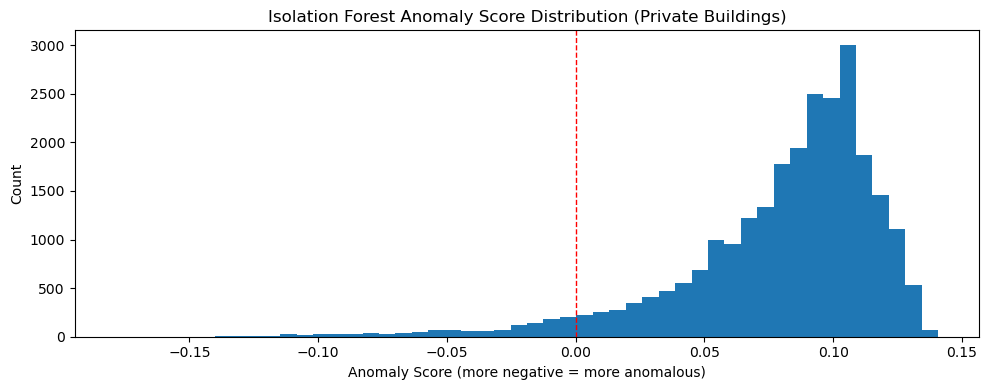

In [305]:
plt.figure(figsize=(10, 4))
plt.hist(if_scores, bins=50)
plt.axvline(x=0, color='red', linestyle='--', linewidth=1)
plt.title('Isolation Forest Anomaly Score Distribution (Private Buildings)')
plt.xlabel('Anomaly Score (more negative = more anomalous)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [306]:
# build the results dataframe so we have something concrete to validate against.
# rejoin the anomaly scores back to the identifier columns so we can see 
# which actual buildings got flagged
# This is a ranked list of the most anomalous buildings with their addresses and
# emissions figures
results_df = model_df[['property_id', 'bbl_clean', 'address_1', 'property_name',
                        'ownername', 'peer_group',
                        'total_location_based_ghg']].copy()

# Reconstruct borough from one-hot encoded columns
borough_cols = [c for c in model_df.columns if c.startswith('borough_')]
results_df['borough'] = model_df[borough_cols].idxmax(axis=1).str.replace('borough_', '')

results_df['if_score'] = if_scores
results_df['if_anomaly'] = if_labels

results_df = results_df.sort_values('if_score', ascending=True)

print(results_df.head(10))

      property_id   bbl_clean             address_1  \
47394     4972273  1016560001     2085-2086 2nd Ave   
55313    15679315  1013730001       595 Main Street   
47854     5925243  2051410120  Co-Op City Boulevard   
41965     4920331  1012927502       432 Park Avenue   
55807    18188313  1010297502  217 West 57th Street   
53467     9948324  1010107506  157 West 57th Street   
47722     5848135  1012877501        641 5th Avenue   
62144    53381792  1002630008               Various   
50920     6675019  1010107506  157 WEST 57TH STREET   
55091    15404602  1007027503  560 West 33rd Street   

                                       property_name  \
47394                            Franklin Plaza 1656   
55313                 Westview - 595-625 Main Street   
47854                                     Co-Op City   
41965         432 Park Condominium (432 Park Avenue)   
55807                           217 West 57th Street   
53467                           157 West 57th Street   
47

### 5.2 Initial Results Analysis

#### Owner Distribution
127 of 986 flagged buildings (12.9%) have no identifiable owner ("UNAVAILABLE OWNER" 
or "NAME NOT ON FILE"). At 7.3% of unknown-owner buildings flagged versus 5% baseline,
unknown ownership correlates modestly with anomalous reporting — these buildings are 
harder to hold accountable and warrant priority attention.

#### Peer Group Bias
xl buildings represent 6.5% of the private dataset but 80.9% of flagged anomalies — 
a 12x overrepresentation. The model is partly detecting scale-related structural 
differences rather than pure reporting anomalies. Large campus-style buildings behave 
differently from typical multifamily buildings even within the xl peer group. 

This is the primary limitation of the MVP. Two refinement paths for future iterations:
- Run separate models by peer group so xl buildings are only compared against other 
xl buildings
- Add size-normalized features (emissions per unit, emissions per square foot) to 
reduce the raw scale signal

In [307]:
flagged = results_df[results_df['if_anomaly'] == -1]
print(flagged['ownername'].value_counts().head(10))

ownername
UNAVAILABLE OWNER                 150
BSC HOUSING COMPANY, INC.          35
BPP ST OWNER LLC                   22
NYC HOUSING DEVELOPMENT CORP.      13
LONDON TERRACE GARDENS             12
IP MORTGAGE BORROWER LLC           11
THE GREENWICH LANE CONDOMINIUM      9
SOUTHBRIDGE TOWERS INC              9
QUEENS FRESH MEADOWS, LLC           8
BPP KIPS BAY HOLDING LLC            8
Name: count, dtype: int64


In [308]:
print(flagged_private['peer_group'].value_counts())

peer_group
post_war_xl        235
recent_xl          183
late_20c_xl        181
modern_xl          127
pre_war_xl          72
post_war_large      66
late_20c_large      27
pre_war_small       26
post_war_small      25
recent_large         8
modern_large         7
post_war_medium      6
late_20c_small       6
pre_war_large        5
pre_war_medium       4
recent_medium        3
recent_small         2
modern_small         2
late_20c_medium      1
Name: count, dtype: int64


In [309]:
total_unavailable = model_df[model_df['ownername'] == 'UNAVAILABLE OWNER'].shape[0]
print(f"Unavailable owner flagged: 127 / {total_unavailable} ({127/total_unavailable:.1%})")

Unavailable owner flagged: 127 / 2117 (6.0%)


In [310]:
xl_buildings = model_df[model_df['peer_group'].str.endswith('xl')].shape[0]
print(f"XL buildings: {xl_buildings} / {model_df.shape[0]} ({xl_buildings/model_df.shape[0]:.1%})")
print(f"XL flagged: 798 / 986 ({798/986:.1%})")

XL buildings: 1407 / 25709 (5.5%)
XL flagged: 798 / 986 (80.9%)


In [311]:
# contaimination sensitivity

contamination_values = [0.03, 0.05, 0.10]
sensitivity_results = {}

for c in contamination_values:
    iso = IsolationForest(contamination=c, random_state=42)
    iso.fit(X)
    labels = iso.predict(X)
    flagged_ids = set(model_df[labels == -1]['property_id'])
    sensitivity_results[c] = flagged_ids
    print(f"contamination={c}: {len(flagged_ids)} buildings flagged")

# Check overlap — buildings flagged across all three values are most robust
core_anomalies = sensitivity_results[0.03] & sensitivity_results[0.05] & sensitivity_results[0.10]
print(f"\nFlagged at all three contamination levels: {len(core_anomalies)}")
print(f"Share of 0.05 flagged set: {len(core_anomalies)/len(sensitivity_results[0.05]):.1%}")

contamination=0.03: 772 buildings flagged
contamination=0.05: 1268 buildings flagged
contamination=0.1: 2571 buildings flagged

Flagged at all three contamination levels: 772
Share of 0.05 flagged set: 60.9%


In [312]:
core_df = results_df[results_df['property_id'].isin(core_anomalies)]
print(core_df['peer_group'].value_counts())
print(f"\nXL share of core anomalies: {core_df['peer_group'].str.endswith('xl').mean():.1%}")

peer_group
post_war_xl        195
recent_xl          153
late_20c_xl        147
modern_xl           80
pre_war_xl          55
late_20c_large      31
post_war_large      29
recent_large        23
recent_medium       11
late_20c_medium      7
modern_large         6
recent_small         6
pre_war_medium       6
post_war_small       5
late_20c_small       5
pre_war_small        5
pre_war_large        5
post_war_medium      1
modern_small         1
modern_medium        1
Name: count, dtype: int64

XL share of core anomalies: 81.6%


In [313]:
print(f"XL share of core anomalies: {core_df['peer_group'].str.endswith('xl').mean():.1%}")

XL share of core anomalies: 81.6%


In [314]:
core_non_xl = core_df[~core_df['peer_group'].str.endswith('xl')]
print(core_non_xl[['address_1', 'property_name', 'ownername', 
                    'peer_group', 'total_location_based_ghg', 
                    'if_score']].head(20))

                    address_1                                  property_name  \
57412   230 East 123rd Street                          230 East 123rd Street   
42536  364 A Greenwich Street               Stellar - 364 A Greenwich Street   
48216      150 Brielle Avenue   Park Lane at Sea View (Prescriptive Pathway)   
42007             312 8th Ave  Mutual Redevelopment -Penn South - Building 4   
46128     169-65 137th Avenue                     Rochdale Village - 4436332   
54166   324 East 108th Street                                 324 E 108th St   
54167         2078 2nd Avenue                                   2078 2nd Ave   
54169            2065 1st Ave                                   2065 1st Ave   
54170   325 East 106th Street                                 325 E 106th St   
47396            2086 2nd Ave                                   2086 2nd Ave   
54165   334 East 108th Street                                 334 E 108th St   
54168   315 East 106th Street           

> **Revision note:** Initial model flagged NYCHA buildings at 40% vs 4% for private 
> buildings. Dataset split into private and NYCHA populations after this finding. 
> All downstream cells reflect private buildings only.

> **Revision note:** Initial results showed 80.9% of flagged buildings were xl peer 
> group despite representing only 6.5% of the dataset. Three size-normalized features 
> added (`ghg_per_sqft`, `ghg_per_unit`, `site_eui_per_unit`) to reduce scale bias. 
> 220 buildings with implausible square footage and 253 buildings with fewer than 5 
> units had derived features nulled before imputation.

In [315]:
# # What share of total NYCHA buildings are flagged?
# total_nycha = model_df[model_df['ownername'] == 'NYC HOUSING AUTHORITY'].shape[0]
# print(f"NYCHA flagged: 201 / {total_nycha} ({201/total_nycha:.1%})")

# # What's the flagged rate for non-NYCHA buildings?
# non_nycha_flagged = flagged[flagged['ownername'] != 'NYC HOUSING AUTHORITY'].shape[0]
# non_nycha_total = model_df[model_df['ownername'] != 'NYC HOUSING AUTHORITY'].shape[0]
# print(f"Non-NYCHA flagged: {non_nycha_flagged} / {non_nycha_total} ({non_nycha_flagged/non_nycha_total:.1%})")

### 5.2 Local Outlier Factor
### 5.3 Anomaly Score Distribution
### 5.4 Cross-reference Against DOB Violations